# Progetto AOCR: Valutazione e Ottimizzazione del Servizio di Prestito Interbibliotecario
**Caso di Studio: Provincia di Brescia**

Questo notebook implementa un approccio a due fasi (First-Cluster-Then-Route) per ottimizzare la logistica del sistema bibliotecario. 
Il problema è modellato considerando vincoli avanzati (Rich VRP) quali:
* **Pickup & Delivery Simultaneo**: Ad ogni fermata si scaricano e caricano libri.
* **Time Windows**: Rispetto degli orari di apertura e chiusura delle librerie.
* **Flotta Eterogenea**: Utilizzo di veicoli con capacità di carico differenti.

In [6]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import math
import copy
import matplotlib.pyplot as plt

# Fissiamo il seed per garantire la riproducibilità dei risultati
np.random.seed(42)

# ==========================================
# SETUP DATI UFFICIALI DEL PAPER
# ==========================================
TOT_LIBRARIES = 210 # Numero totale di librerie nella provincia di Brescia
P_CLUSTERS = 8      # Numero di cluster in cui è suddivisa la rete

# Generiamo coordinate casuali per simulare l'intera provincia
coords_all = np.random.rand(TOT_LIBRARIES, 2) * 200

# Calcoliamo la matrice delle distanze (Euclidea) tra tutte le 210 librerie
dist_all = np.zeros((TOT_LIBRARIES, TOT_LIBRARIES))
for i in range(TOT_LIBRARIES):
    for j in range(TOT_LIBRARIES):
        dist_all[i][j] = math.sqrt((coords_all[i][0] - coords_all[j][0])**2 + (coords_all[i][1] - coords_all[j][1])**2)

print(f"Dati globali inizializzati: {TOT_LIBRARIES} librerie da dividere in {P_CLUSTERS} cluster.")

Dati globali inizializzati: 210 librerie da dividere in 8 cluster.


## FASE 1: Clustering tramite Modello della $p$-Mediana
Data la vastità del territorio (210 librerie), il problema di routing globale risulta computazionalmente intrattabile. Utilizziamo il modello di localizzazione della $p$-mediana per suddividere il territorio in $p=8$ cluster ottimi, minimizzando la distanza di ciascuna libreria dal centro del proprio cluster.
Successivamente, un codice "ponte" estrarrà il cluster più grande per passarlo alla fase di routing.

In [7]:
print("--- Avvio Modello p-Mediana ---")
model_pmed = gp.Model("p-mediana")
model_pmed.setParam('OutputFlag', 0) # Nascondiamo il log per pulizia visiva

# Variabili decisionali
y = model_pmed.addVars(TOT_LIBRARIES, vtype=GRB.BINARY, name="y") # 1 se il nodo è un centro
x = model_pmed.addVars(TOT_LIBRARIES, TOT_LIBRARIES, vtype=GRB.BINARY, name="x") # 1 se i è assegnato a j

# Funzione Obiettivo: Minimizzare la somma delle distanze
model_pmed.setObjective(gp.quicksum(dist_all[i][j] * x[i, j] for i in range(TOT_LIBRARIES) for j in range(TOT_LIBRARIES)), GRB.MINIMIZE)

# Vincoli del modello
model_pmed.addConstr(gp.quicksum(y[j] for j in range(TOT_LIBRARIES)) == P_CLUSTERS) # Esattamente P cluster
for i in range(TOT_LIBRARIES):
    model_pmed.addConstr(gp.quicksum(x[i, j] for j in range(TOT_LIBRARIES)) == 1) # Ogni libreria assegnata a 1 solo centro
    for j in range(TOT_LIBRARIES):
        model_pmed.addConstr(x[i, j] <= y[j]) # Assegnamento valido solo se j è aperto

model_pmed.optimize()

# Estrazione dei cluster formati
clusters = {j: [] for j in range(TOT_LIBRARIES) if y[j].x > 0.5}
for i in range(TOT_LIBRARIES):
    for j in clusters.keys():
        if x[i, j].x > 0.5:
            clusters[j].append(i)

# --- CODICE PONTE: ESTRAZIONE DEL CLUSTER PIÙ GRANDE ---
id_centro_scelto = max(clusters, key=lambda k: len(clusters[k]))
nodi_cluster = clusters[id_centro_scelto]
N = len(nodi_cluster) + 1 # Nodi del cluster + 1 Deposito Centrale

# Prepariamo le strutture dati isolate per il routing di questo singolo cluster
coords = np.zeros((N, 2))
coords[0] = [100, 100] # Deposito posizionato al centro mappa

for local_idx, global_node in enumerate(nodi_cluster):
    coords[local_idx + 1] = coords_all[global_node]

dist = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        dist[i][j] = math.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)

print(f"Fase 1 completata. Selezionato il cluster più popoloso con {N-1} librerie.")

--- Avvio Modello p-Mediana ---
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2827288
Academic license 2827288 - for non-commercial use only - registered to ca___@studenti.unina.it
Fase 1 completata. Selezionato il cluster più popoloso con 37 librerie.


## Visualizzazione del Clustering
Di seguito viene mostrato il territorio provinciale prima e dopo l'applicazione del modello di localizzazione. A sinistra è visibile la distribuzione casuale delle 210 librerie; a destra, il risultato dell'ottimizzazione tramite $p$-mediana, con le librerie assegnate ai rispettivi centri (evidenziati a forma di stella).


--- Generazione Grafici Clustering ---


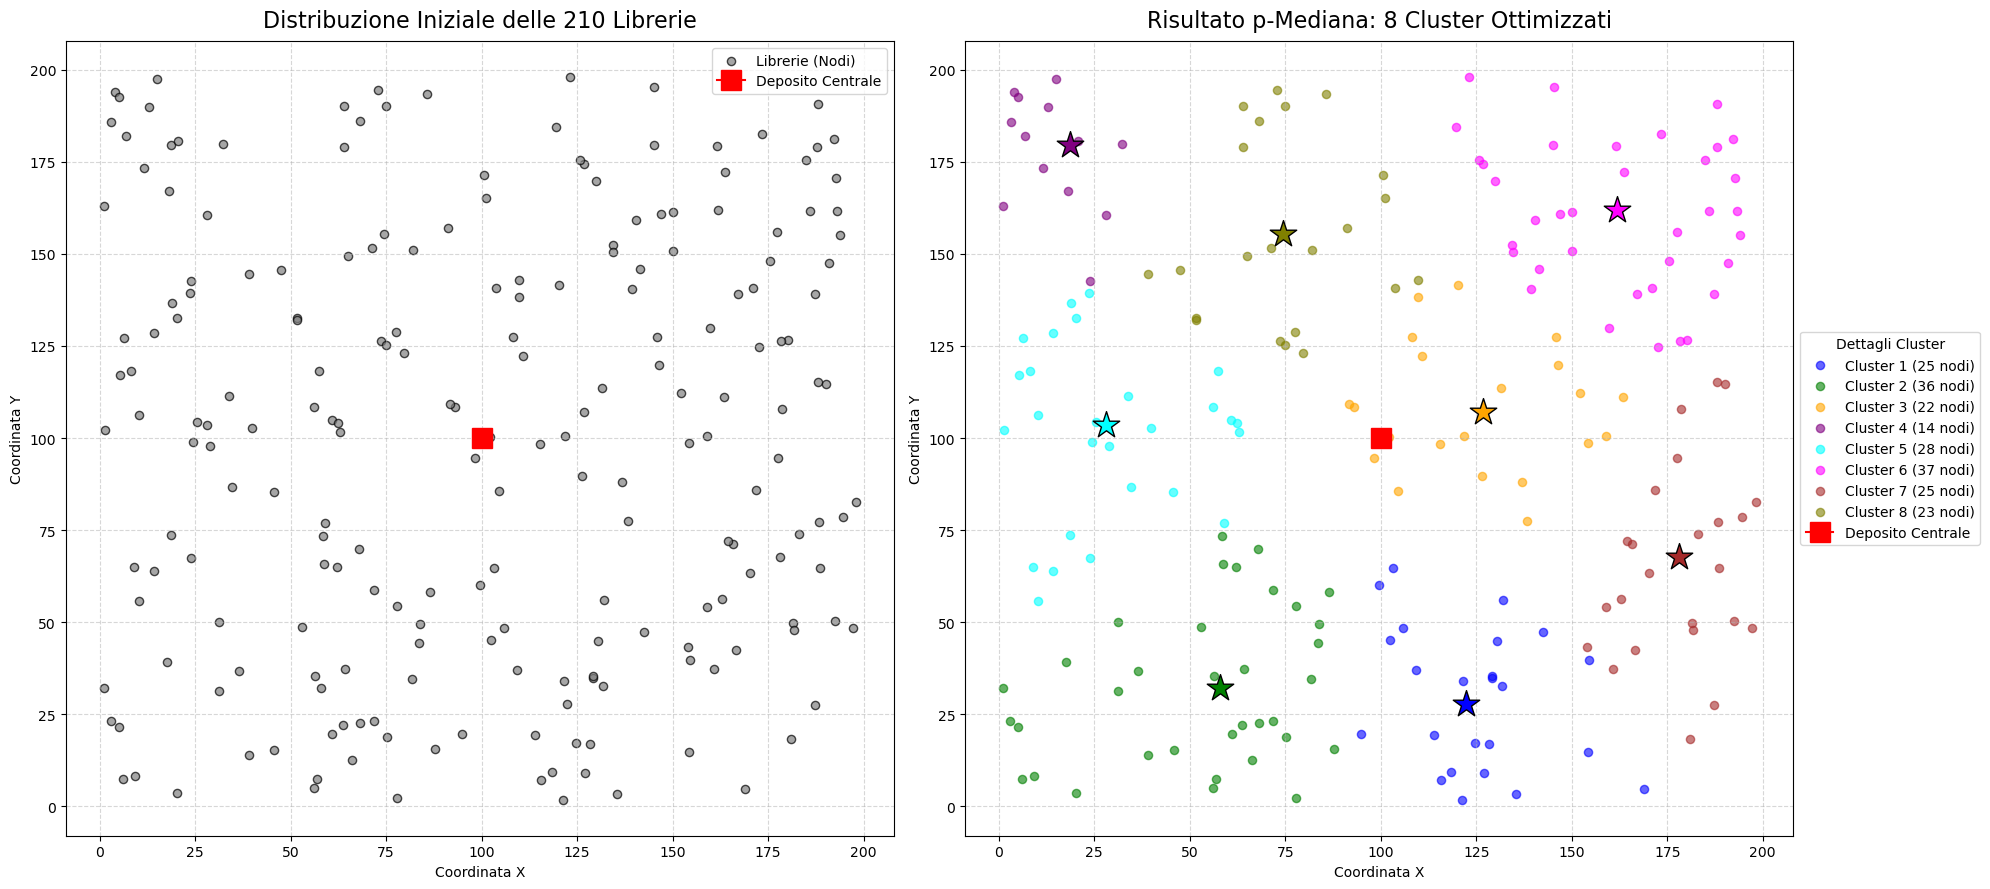

In [8]:
# ==========================================
# VISUALIZZAZIONE FASE 1: PRIMA E DOPO IL CLUSTERING
# ==========================================
print("\n--- Generazione Grafici Clustering ---")

# Creiamo una figura con due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Coordinate fisse del Deposito Centrale (le stesse usate poi nel routing)
depot_coords = [100, 100]

# ---------------------------------------------------------
# GRAFICO 1: PRIMA DEL CLUSTERING
# ---------------------------------------------------------
ax1 = axes[0]
# Estraiamo le coordinate x e y di tutte le 210 librerie
x_all = [coords_all[i][0] for i in range(TOT_LIBRARIES)]
y_all = [coords_all[i][1] for i in range(TOT_LIBRARIES)]

# Disegniamo tutte le librerie in grigio per mostrare il disordine iniziale
ax1.scatter(x_all, y_all, c='gray', alpha=0.7, edgecolors='black', s=35, label='Librerie (Nodi)')

# Aggiungiamo il Deposito Centrale
ax1.plot(depot_coords[0], depot_coords[1], marker='s', color='red', 
         markersize=14, zorder=10, label='Deposito Centrale')

ax1.set_title(f'Distribuzione Iniziale delle {TOT_LIBRARIES} Librerie', fontsize=16, pad=10)
ax1.set_xlabel('Coordinata X')
ax1.set_ylabel('Coordinata Y')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# GRAFICO 2: DOPO IL CLUSTERING (p-Mediana)
# ---------------------------------------------------------
ax2 = axes[1]
colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'olive']

# Disegniamo ogni cluster con un colore diverso
cluster_list = list(clusters.values())
for idx, cluster_nodes in enumerate(cluster_list):
    color = colors[idx % len(colors)]
    x_c = [coords_all[node][0] for node in cluster_nodes]
    y_c = [coords_all[node][1] for node in cluster_nodes]
    
    # Disegniamo i nodi normali appartenenti al cluster
    ax2.scatter(x_c, y_c, c=color, alpha=0.6, s=35, label=f'Cluster {idx+1} ({len(cluster_nodes)} nodi)')
    
    # Evidenziamo il centro del cluster (stella grande)
    center_node = list(clusters.keys())[idx]
    ax2.scatter(coords_all[center_node][0], coords_all[center_node][1], 
                c=color, marker='*', s=400, edgecolors='black', zorder=5)

# Aggiungiamo il Deposito Centrale anche qui
ax2.plot(depot_coords[0], depot_coords[1], marker='s', color='red', 
         markersize=14, zorder=10, label='Deposito Centrale')

ax2.set_title(f'Risultato p-Mediana: {P_CLUSTERS} Cluster Ottimizzati', fontsize=16, pad=10)
ax2.set_xlabel('Coordinata X')
ax2.set_ylabel('Coordinata Y')

# Spostiamo la legenda all'esterno del grafico per non coprire i punti
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title="Dettagli Cluster")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

## Setup Parametri Rich VRP e Oracolo di Ammissibilità
Per modellare accuratamente il caso reale descritto nel paper, generiamo le domande di *Pickup & Delivery* e le *Time Windows*. 
Inoltre, definiamo la funzione `is_route_feasible`, che funge da "oracolo": simula un percorso e restituisce esito positivo solo se i vincoli di tempo, capacità incrociata e flotta vengono rigorosamente rispettati.

In [9]:
import numpy as np


#  GENERAZIONE DEI VINCOLI OPERATIVI 

# A. Domanda Pickup & Delivery Simultaneo (VRPSPD)
# Ogni libreria richiede sia la consegna di nuovi libri (Delivery) che il ritiro di resi (Pickup).
deliveries = np.random.randint(1, 8, N) 
pickups = np.random.randint(1, 8, N)    
deliveries[0] = pickups[0] = 0 # Il nodo 0 (Deposito) non ha domanda intrinseca

# B. Finestre Temporali e Tempi di Servizio 
tw_start = np.zeros(N)
# Orizzonte temporale base: 480 minuti (es. turno standard 8:00 - 16:00)
tw_end = np.full(N, 480) 
service_time = 15 # Tempo fisso di permanenza al nodo (sosta per operazioni di carico/scarico)

# Generazione di Hard Time Windows (Finestre Temporali Rigide)
for i in range(1, N):
    if np.random.rand() > 0.5: # Con probabilità del 50%, la libreria ha orari ristretti
        tw_start[i] = np.random.randint(0, 200)
        tw_end[i] = tw_start[i] + np.random.randint(120, 240) # Finestra di ampiezza 2-4 ore
# Il deposito gode di un orizzonte esteso (600 min) per permettere l'uscita anticipata e il rientro ritardato
tw_start[0], tw_end[0] = 0, 600 

# C. Flotta Eterogenea 
# A differenza del CVRP teorico, la flotta ha capacità variabili (es. furgoni piccoli, medi e grandi).
# Il vettore è ordinato in modo crescente per ottimizzare l'assegnazione (algoritmo First-Fit).
fleet_capacities = [30, 30, 30, 50, 50, 80]
fleet_capacities.sort()


#  ORACOLO DI AMMISSIBILITÀ (FEASIBILITY CHECK) 

def is_route_feasible(route):
    """
    Funzione Oracolo Deterministica. Valuta se una sequenza di nodi (rotta) 
    soddisfa congiuntamente tutti i vincoli operativi del Rich VRP.
    
    Output: 
    - Tuple (is_feasible: bool, route_cost: float, assigned_capacity: int)
    """
    current_time = 0
    
    # --- 1. VERIFICA DEI VINCOLI TEMPORALI (Time Windows) ---
    for k in range(len(route) - 1):
        curr_node, next_node = route[k], route[k+1]
        
        # Aggiunge il tempo di percorrenza (assumendo velocità costante, Distanza = Tempo)
        current_time += dist[curr_node][next_node] 
        
        # Gestione Arrivi Anticipati: se il mezzo arriva prima dell'apertura, subisce un'attesa forzata.
        if current_time < tw_start[next_node]:
            current_time = tw_start[next_node] 
            
        # Gestione Arrivi Ritardati: la Time Window è 'Hard', la violazione rende lo stato inammissibile.
        if current_time > tw_end[next_node]:
            return False, float('inf'), None 
            
        # Se il nodo visitato è un cliente (non il deposito), somma il tempo di servizio.
        if next_node != 0:
            current_time += service_time

    # --- 2. VERIFICA FLUTTUAZIONE DEL CARICO ---
    # Nel CVRP classico il carico decresce monotonicamente. Nel nostro caso fluttua.
    # Il mezzo deve partire dal deposito con TUTTA la merce da consegnare nella rotta.
    current_load = sum(deliveries[node] for node in route) 
    max_load_reached = current_load # Inizializzazione del picco massimo di carico
    
    # Ricalcolo dinamico del volume a bordo dopo ogni sosta
    for node in route[1:-1]:
        # Scarica le consegne (libera spazio) e carica i ritiri (occupa spazio)
        current_load = current_load - deliveries[node] + pickups[node]
        
        # Registra il picco massimo raggiunto durante l'intero tragitto
        if current_load > max_load_reached:
            max_load_reached = current_load
            
    # --- 3. ASSEGNAZIONE DEL MEZZO OTTIMALE  ---
    # Ricerca il furgone più piccolo in grado di gestire il "max_load_reached" (First-Fit).
    assigned_vehicle_cap = None
    for cap in fleet_capacities:
        if max_load_reached <= cap:
            assigned_vehicle_cap = cap
            break # Trovato il mezzo idoneo più economico
            
    # Se il picco di carico supera la portata del furgone più capiente (80), la rotta è impercorribile.
    if assigned_vehicle_cap is None:
        return False, float('inf'), None 

    # --- 4. CALCOLO DELLA FUNZIONE OBIETTIVO ---
    # Se tutti i controlli sono superati, calcola il costo di puro routing (distanza euclidea).
    cost = sum(dist[route[k]][route[k+1]] for k in range(len(route)-1))
    
    return True, cost, assigned_vehicle_cap

## FASE 2: Routing Iniziale (Algoritmo di Clarke & Wright Adattato)
L'euristica costruttiva dei Risparmi (*Savings Algorithm*) viene utilizzata per generare una soluzione iniziale rapida. L'algoritmo calcola i risparmi ottenibili fondendo due rotte e interroga la funzione `is_route_feasible` prima di confermare ogni unione.

In [10]:
print("--- Esecuzione Clarke & Wright (Rich VRP) ---")

# --- 1. INIZIALIZZAZIONE (Soluzione Base) ---
# Si parte dalla soluzione peggiore ammissibile ("back-and-forth" o rotte a spola):
# Un veicolo dedicato per ogni singola libreria, che parte dal deposito (0), visita 'i', e torna (0).
routes = [[0, i, 0] for i in range(1, N)]

# --- 2. CALCOLO DEI RISPARMI (SAVINGS MATRIX) ---
# Calcolo del "risparmio" (saving) chilometrico ottenuto visitando i e j consecutivamente 
# invece che con due rotte separate che rientrano al deposito.
# Formula matematica di Clarke & Wright: s_ij = c_i0 + c_0j - c_ij
savings = [(dist[i][0] + dist[0][j] - dist[i][j], i, j) for i in range(1, N) for j in range(1, N) if i != j]

# Ordinamento Greedy (Miope): dal risparmio chilometrico maggiore a quello minore.
# L'algoritmo cercherà di applicare sempre le fusioni più convenienti per prime.
savings.sort(key=lambda x: x[0], reverse=True) 

# --- 3. FUSIONE ITERATIVA DELLE ROTTE (MERGING) ---
for saving, i, j in savings:
    # Cerca la rotta in cui il nodo 'i' è l'ULTIMO cliente visitato prima del ritorno al deposito (posizione r[-2])
    route_i_idx = next((idx for idx, r in enumerate(routes) if i in r and r[-2] == i), -1)
    
    # Cerca la rotta in cui il nodo 'j' è il PRIMO cliente visitato dopo la partenza dal deposito (posizione r[1])
    route_j_idx = next((idx for idx, r in enumerate(routes) if j in r and r[1] == j), -1)
    
    # Condizioni di invalidità (skip): 
    # 1. 'i' o 'j' non sono punti estremi delle loro rotte (sono clienti intermedi).
    # 2. 'i' e 'j' appartengono già alla stessa rotta (funderli creerebbe un "subtour" o ciclo chiuso invalido).
    if route_i_idx == -1 or route_j_idx == -1 or route_i_idx == route_j_idx:
        continue
        
    route_i, route_j = routes[route_i_idx], routes[route_j_idx]
    
    # Unione Topologica: salda la fine della rotta 'i' con l'inizio della rotta 'j',
    # eliminando il rientro intermedio al deposito (lo '0' finale di i e lo '0' iniziale di j).
    # Esempio: [0, a, i, 0] + [0, j, b, 0] -> [0, a, i, j, b, 0]
    merged_route = route_i[:-1] + route_j[1:] 
    
    # --- VALIDAZIONE "RICH VRP" TRAMITE ORACOLO ---
    # A differenza del VRP classico (CVRP), non basta calcolare il peso a bordo.
    # L'Oracolo verifica i vincoli incrociati e dinamici: rispetto delle Time Windows, 
    # fluttuazione del carico per Pickup & Delivery, e disponibilità di un veicolo idoneo.
    is_feasible, _, _ = is_route_feasible(merged_route)
    
    if is_feasible:
        # Se la rotta fusa è operativamente fattibile, consolidiamo la mossa sostituendo la vecchia
        # rotta 'i' con quella unita, e cancellando la vecchia rotta 'j' (ormai assorbita).
        routes[route_i_idx] = merged_route
        del routes[route_j_idx]

# --- 4. VALUTAZIONE FINALE E REPORTING ---
total_cost_cw = 0
for idx, route in enumerate(routes):
    # Richiama l'oracolo un'ultima volta per estrarre il costo definitivo della singola rotta
    # e il tipo di furgone (v_cap) che è stato dinamicamente assegnato.
    _, r_cost, v_cap = is_route_feasible(route)
    total_cost_cw += r_cost
    print(f"Rotta C&W {idx+1}: {route} | Cap: {v_cap} | Costo: {r_cost:.2f}")

print(f"\nCosto Iniziale (C&W): {total_cost_cw:.2f}")

--- Esecuzione Clarke & Wright (Rich VRP) ---
Rotta C&W 1: [0, 15, 22, 20, 30, 7, 2, 1, 19, 18, 32, 3, 12, 25, 9, 34, 0] | Cap: 80 | Costo: 335.39
Rotta C&W 2: [0, 26, 29, 31, 13, 17, 6, 11, 0] | Cap: 30 | Costo: 217.10
Rotta C&W 3: [0, 37, 27, 35, 16, 8, 33, 4, 21, 28, 14, 10, 24, 36, 5, 23, 0] | Cap: 80 | Costo: 292.10

Costo Iniziale (C&W): 844.59


## FASE 3: Ottimizzazione Metaeuristica (Tabu Search)
Ispirata all'algoritmo TABUROUTE, questa fase esplora l'intorno della soluzione iniziale tramite mosse di tipo *Relocate* (spostamento di un nodo tra rotte diverse).
Una *Tabu List* impedisce che un nodo appena spostato venga mosso nuovamente per un certo numero di iterazioni (*Tabu Tenure*), permettendo all'algoritmo di scappare dagli ottimi locali.

In [11]:
print("\n--- Avvio Tabu Search (Rich VRP) ---")

# --- PARAMETRI DI TUNING DELLA METAEURISTICA ---
# MAX_ITER: Criterio di arresto. Definisce il limite massimo di esplorazioni dello spazio delle soluzioni.
# TABU_TENURE: Parametro di diversificazione. Indica per quante iterazioni un nodo mosso diventa "intoccabile".
MAX_ITER = 300
TABU_TENURE = 15

# --- INIZIALIZZAZIONE DELLO STATO ---
# Si imposta la soluzione iniziale (fornita dall'euristica costruttiva di Clarke & Wright)
# come l'attuale Best-Known Solution (Ottimo Globale storico) e come Stato Corrente.
best_routes, best_cost = copy.deepcopy(routes), total_cost_cw
current_routes, current_cost = copy.deepcopy(routes), total_cost_cw

# Struttura dati per la Memoria a Breve Termine (Tabu List).
# Memorizza le restrizioni nel formato {id_nodo: iterazione_di_scadenza_tabu}
tabu_list = {}

def evaluate_rich_routes(routes_to_eval):
    """
    Funzione Oracolo di aggregazione: valuta l'ammissibilità dell'intero set di rotte 
    in risposta a una perturbazione (mossa). Se anche una sola rotta viola i vincoli
    del Rich VRP (Capacità o Time Windows), l'intera mossa viene scartata.
    """
    total = 0
    for r in routes_to_eval:
        feasible, cost, _ = is_route_feasible(r)
        if not feasible: return False, float('inf')
        total += cost
    return True, total

# --- CICLO PRINCIPALE DI RICERCA ---
for iteration in range(MAX_ITER):
    neighborhood = [] # Insieme delle soluzioni vicine ammissibili N(s)
    
    # --- 1. ESPLORAZIONE DELL'INTORNO (OPERATORE RELOCATE) ---
    # L'algoritmo valuta lo spostamento di ogni singolo nodo da una rotta di origine a una di destinazione.
    for r1_idx, r1 in enumerate(current_routes):
        for r2_idx, r2 in enumerate(current_routes):
            if r1_idx != r2_idx: # Vieta lo spostamento intra-rotta (sulla stessa rotta)
                for i in range(1, len(r1)-1): # Esclude i nodi deposito (0) della rotta di origine
                    node = r1[i]
                    for j in range(1, len(r2)): # Valuta ogni possibile punto di inserimento nella rotta di destinazione
                        
                        # Costruzione della mossa: estrazione da r1 e inserimento in r2
                        new_r1, new_r2 = r1[:i] + r1[i+1:], r2[:j] + [node] + r2[j:]
                        
                        # Generazione dello stato perturbato
                        temp_routes = copy.deepcopy(current_routes)
                        temp_routes[r1_idx], temp_routes[r2_idx] = new_r1, new_r2
                        
                        # Valutazione di ammissibilità della mossa
                        is_feasible, temp_cost = evaluate_rich_routes(temp_routes)
                        if is_feasible:
                            # Se la mossa è ammissibile, viene aggiunta all'intorno
                            neighborhood.append({'move': (node, r1_idx), 'routes': temp_routes, 'cost': temp_cost})

    # Criterio di arresto anticipato: se lo spazio delle soluzioni è completamente bloccato dai vincoli
    if not neighborhood: break 
    
    # Ordinamento "Best-Improvement": si valuta prima la mossa che minimizza maggiormente il costo
    neighborhood.sort(key=lambda x: x['cost'])
    
    move_accepted = False
    
    # --- 2. VALUTAZIONE DELLE MOSSE E GESTIONE TABU ---
    for candidate in neighborhood:
        node, cand_cost = candidate['move'][0], candidate['cost']
        
        # Verifica dello status Tabu: la mossa è vietata se l'iterazione corrente non ha ancora superato la scadenza
        is_tabu = tabu_list.get(node, 0) > iteration
        
        # --- CRITERIO DI ASPIRAZIONE ---
        # Se la mossa è Tabu, ma produce una soluzione strettamente migliore dell'Ottimo Globale storico,
        # lo status Tabu viene revocato. Questa è la valvola di sicurezza per non perdere l'ottimo assoluto.
        if is_tabu and cand_cost < best_cost: 
            is_tabu = False
            
        # Se la mossa è ammissibile e non Tabu (o aspirata), viene accettata
        if not is_tabu:
            # Transizione allo stato successivo
            current_routes, current_cost = candidate['routes'], cand_cost
            
            # Penalizzazione: il nodo appena mosso viene inserito nella Tabu List per TABU_TENURE iterazioni
            tabu_list[node] = iteration + TABU_TENURE 
            
            # Aggiornamento dell'Ottimo Globale (Best-Known Solution)
            if current_cost < best_cost:
                best_cost, best_routes = current_cost, copy.deepcopy(current_routes)
                
            move_accepted = True
            break # Uscita dal ciclo di valutazione dell'intorno
            
    # --- 3. VALVOLA ANTI-STALLO ---
    # Se TUTTE le mosse dell'intorno erano Tabu e nessuna ha soddisfatto il Criterio di Aspirazione,
    # l'algoritmo accetta forzatamente la MIGLIORE mossa Tabu per sbloccare la ricerca ed esplorare nuove aree.
    if not move_accepted:
        current_routes, current_cost = neighborhood[0]['routes'], neighborhood[0]['cost']
        tabu_list[neighborhood[0]['move'][0]] = iteration + TABU_TENURE

print(f"Ottimizzazione completata. Costo Finale (TS): {best_cost:.2f}")


--- Avvio Tabu Search (Rich VRP) ---
Ottimizzazione completata. Costo Finale (TS): 814.87


## Visualizzazione e Confronto delle Rotte
Il codice seguente genera un plot affiancato per confrontare visivamente l'assegnazione spaziale delle librerie e gli incroci tra l'euristica costruttiva (a sinistra) e la metaeuristica di miglioramento (a destra).

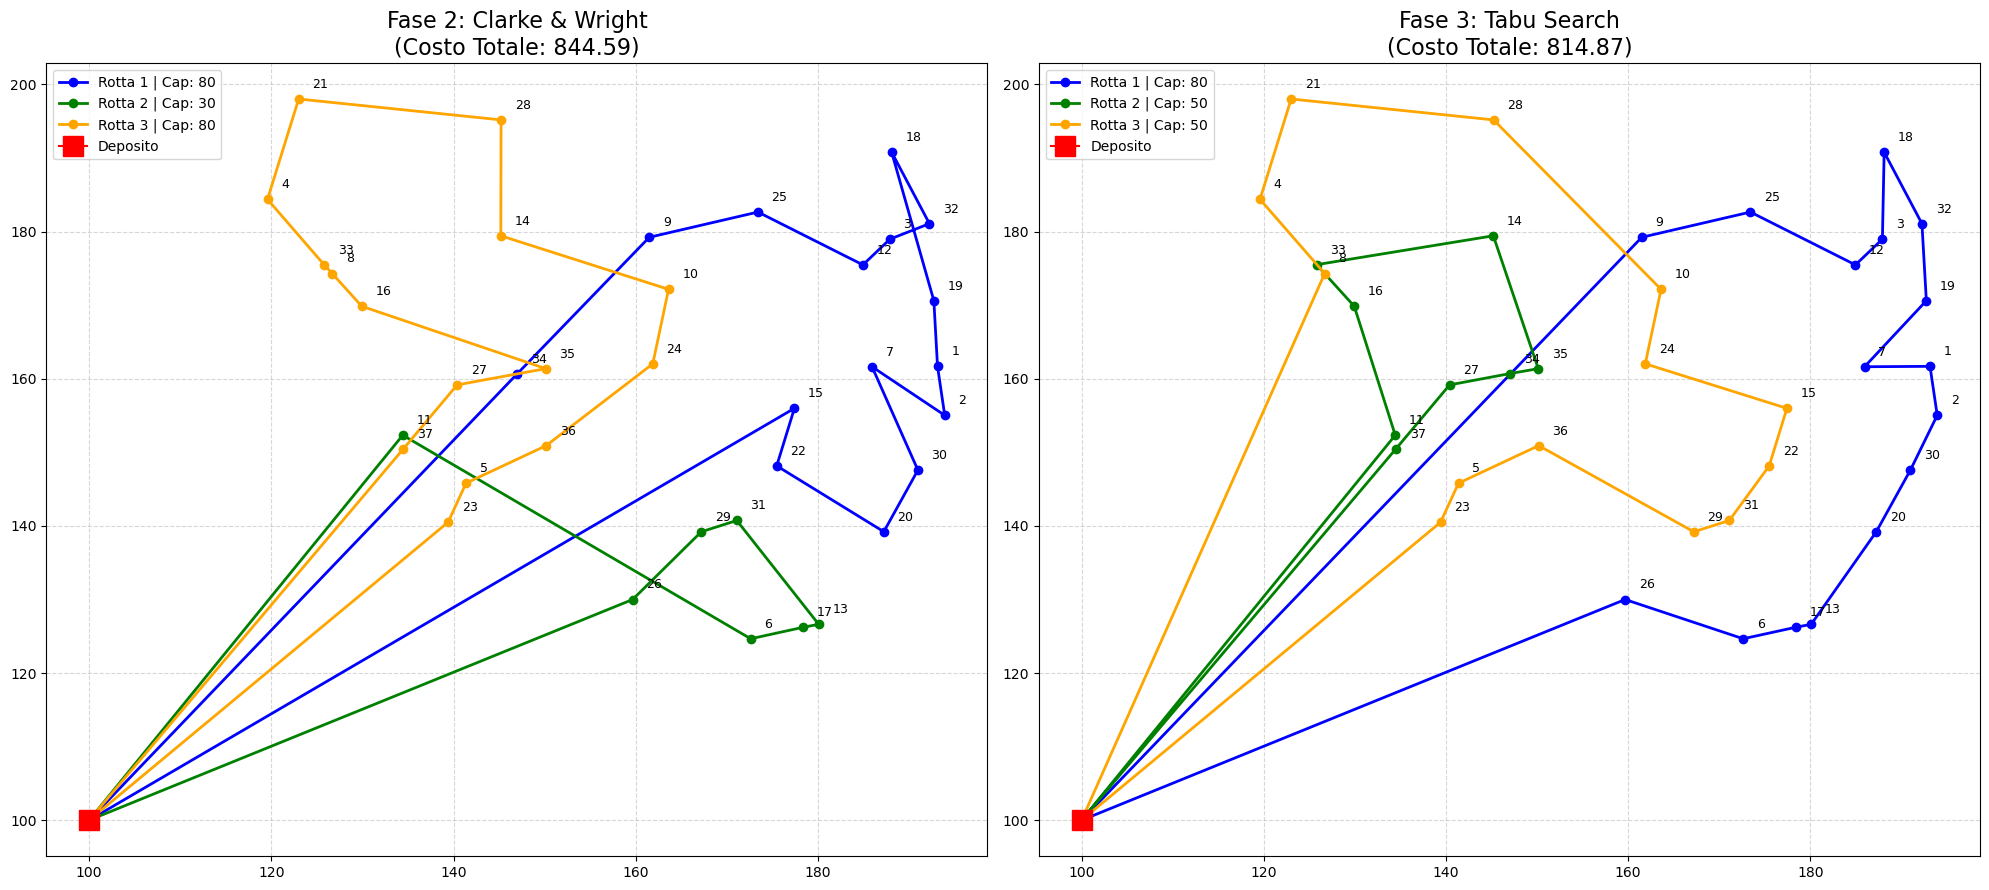

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'olive']

# PLOT 1: Clarke & Wright
ax1 = axes[0]
for idx, route in enumerate(routes): 
    color = colors[idx % len(colors)]
    x_c, y_c = [coords[n][0] for n in route], [coords[n][1] for n in route]
    _, r_cost, v_cap = is_route_feasible(route)
    ax1.plot(x_c, y_c, marker='o', linestyle='-', color=color, linewidth=2, label=f'Rotta {idx+1} | Cap: {v_cap}')

ax1.plot(coords[0][0], coords[0][1], marker='s', color='red', markersize=14, zorder=5, label='Deposito')
for i in range(1, N): ax1.text(coords[i][0] + 1.5, coords[i][1] + 1.5, str(i), fontsize=9)
ax1.set_title(f'Fase 2: Clarke & Wright\n(Costo Totale: {total_cost_cw:.2f})', fontsize=16)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

# PLOT 2: Tabu Search
ax2 = axes[1]
for idx, route in enumerate(best_routes):
    color = colors[idx % len(colors)]
    x_c, y_c = [coords[n][0] for n in route], [coords[n][1] for n in route]
    _, r_cost, v_cap = is_route_feasible(route)
    ax2.plot(x_c, y_c, marker='o', linestyle='-', color=color, linewidth=2, label=f'Rotta {idx+1} | Cap: {v_cap}')

ax2.plot(coords[0][0], coords[0][1], marker='s', color='red', markersize=14, zorder=5, label='Deposito')
for i in range(1, N): ax2.text(coords[i][0] + 1.5, coords[i][1] + 1.5, str(i), fontsize=9)
ax2.set_title(f'Fase 3: Tabu Search\n(Costo Totale: {best_cost:.2f})', fontsize=16)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('confronto_rotte_finale.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Ottimizzazione su Scala Provinciale (System-Wide)
In questa fase finale applichiamo il paradigma *First-Cluster-Then-Route* all'intero territorio.
Per mantenere il codice modulare e pulito, definiremo le tre componenti fondamentali (Oracolo, Clarke & Wright e Tabu Search) come funzioni riutilizzabili, per poi applicarle iterativamente a tutti gli 8 cluster generati nella Fase 1.

**Variabili Globali e Oracolo di Ammissibilità:**
La seguente cella inizializza i contatori per l'intera provincia e definisce l'Oracolo. Questa funzione riceve una potenziale rotta e i dati logistici del cluster, simulando il viaggio per garantire il rispetto delle Time Windows e della capacità eterogenea.

In [13]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import math

# Variabili per le statistiche globali
costo_totale_provincia = 0
furgoni_totali_provincia = 0
labels_cluster = []
costi_cw = []
costi_ts = []

fleet_capacities = [30, 30, 30, 50, 50, 80]
fleet_capacities.sort()
service_time = 15
colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'olive', 'pink', 'gray']

def oracolo_ammissibilita(route, dist, tw_start, tw_end, deliveries, pickups):
    """Simula la rotta e verifica Time Windows e Capacità P&D."""
    current_time = 0
    for k in range(len(route) - 1):
        curr, nxt = route[k], route[k+1]
        current_time += dist[curr][nxt]
        
        if current_time < tw_start[nxt]: current_time = tw_start[nxt] # Attesa
        if current_time > tw_end[nxt]: return False, float('inf'), None # Ritardo
        if nxt != 0: current_time += service_time # Scarico merce
        
    current_load = sum(deliveries[node] for node in route)
    max_load = current_load
    for node in route[1:-1]:
        current_load = current_load - deliveries[node] + pickups[node]
        if current_load > max_load: max_load = current_load
        
    veh_cap = next((cap for cap in fleet_capacities if max_load <= cap), None)
    if veh_cap is None: return False, float('inf'), None
    
    cost = sum(dist[route[k]][route[k+1]] for k in range(len(route)-1))
    return True, cost, veh_cap

### Funzioni di Routing: Clarke & Wright e Tabu Search
* **Clarke & Wright:** Costruisce la soluzione di base unendo le librerie che garantiscono il maggior risparmio chilometrico (senza violare i vincoli imposti dall'oracolo).
* **Tabu Search:** Metaeuristica che esplora l'intorno scambiando nodi tra le rotte per superare l'ottimo locale, dotata di Tabu List e Criterio di Aspirazione.

In [14]:
import copy

def esegui_clarke_wright(N, dist, tw_start, tw_end, deliveries, pickups):
    """
    Euristica Costruttiva: Algoritmo dei Risparmi (Savings) di Clarke & Wright.
    Genera una soluzione iniziale ammissibile partendo da rotte "a spola" (andata e ritorno)
    e fondendole progressivamente in base al maggior risparmio chilometrico.
    """
    
    # 1. INIZIALIZZAZIONE ROTTE
    # Si parte dalla soluzione peggiore ma ammissibile: 1 furgone per ogni libreria.
    # Ogni rotta è nel formato [0, i, 0] dove 0 è il deposito.
    routes = [[0, i, 0] for i in range(1, N)]
    
    # 2. CALCOLO DEI RISPARMI (SAVINGS)
    # Calcoliamo il risparmio ottenuto unendo la rotta per 'i' e quella per 'j'.
    # Formula di Clarke & Wright: S_ij = c_i0 + c_0j - c_ij
    savings = [(dist[i][0] + dist[0][j] - dist[i][j], i, j) 
               for i in range(1, N) for j in range(1, N) if i != j]
               
    # Ordiniamo la lista dei risparmi in ordine decrescente (dal più grande al più piccolo)
    savings.sort(key=lambda x: x[0], reverse=True)
    
    # 3. FUSIONE DELLE ROTTE (MERGING)
    for saving, i, j in savings:
        # Cerca l'indice della rotta in cui il nodo 'i' è l'ULTIMO cliente visitato prima del rientro.
        # Usa r[-2] perché r[-1] è sempre il deposito (nodo 0).
        r_i_idx = next((idx for idx, r in enumerate(routes) if r[-2] == i), -1)
        
        # Cerca l'indice della rotta in cui il nodo 'j' è il PRIMO cliente visitato dopo la partenza.
        # Usa r[1] perché r[0] è sempre il deposito (nodo 0).
        r_j_idx = next((idx for idx, r in enumerate(routes) if r[1] == j), -1)
        
        # Se 'i' o 'j' non sono agli estremi, o appartengono già alla stessa rotta, salta.
        if r_i_idx == -1 or r_j_idx == -1 or r_i_idx == r_j_idx: 
            continue
        
        # Proposta di fusione: unisce la rotta di 'i' (rimuovendo lo 0 finale) 
        # con la rotta di 'j' (rimuovendo lo 0 iniziale).
        merged = routes[r_i_idx][:-1] + routes[r_j_idx][1:]
        
        # Interroga l'Oracolo: la nuova rotta unita rispetta Finestre Temporali e Capacità P&D?
        is_feasible, _, _ = oracolo_ammissibilita(merged, dist, tw_start, tw_end, deliveries, pickups)
        
        if is_feasible:
            # Applica la fusione definitiva e rimuove la vecchia rotta di 'j'
            routes[r_i_idx] = merged
            del routes[r_j_idx]
            
    return routes


def esegui_tabu_search(routes_cw, dist, tw_start, tw_end, deliveries, pickups, iterazioni=100):
    """
    Metaeuristica di Miglioramento: Tabu Search.
    Esplora l'intorno della soluzione fornita da C&W usando un operatore di "Relocate" 
    (sposta un nodo da una rotta all'altra). Usa una memoria a breve termine (Tabu List) 
    per evitare di ricascare in ottimi locali.
    """
    
    # 1. SETUP INIZIALE
    best_routes = copy.deepcopy(routes_cw)
    best_cost = sum(oracolo_ammissibilita(r, dist, tw_start, tw_end, deliveries, pickups)[1] for r in best_routes)
    
    current_routes, current_cost = copy.deepcopy(best_routes), best_cost
    
    # Memoria: un dizionario che associa al 'nodo spostato' l'iterazione fino a cui è "tabù"
    tabu_list = {}
    
    # Funzione ausiliaria per valutare l'ammissibilità e il costo totale di un intero set di rotte
    def eval_routes(rt):
        tot = 0
        for r in rt:
            f, c, _ = oracolo_ammissibilita(r, dist, tw_start, tw_end, deliveries, pickups)
            if not f: return False, float('inf')
            tot += c
        return True, tot
        
    # 2. CICLO DI RICERCA
    for iteration in range(iterazioni):
        neighborhood = [] # Conterrà tutte le mosse ammissibili (lo spazio dell'intorno)
        
        # Generazione dell'intorno: Operatore RELOCATE
        # Sposta il nodo 'i' dalla rotta 'r1' alla posizione 'j' nella rotta 'r2'
        for r1_idx, r1 in enumerate(current_routes):
            for r2_idx, r2 in enumerate(current_routes):
                if r1_idx != r2_idx: # Evita spostamenti all'interno della stessa rotta
                    for i in range(1, len(r1)-1): # Salta i depositi
                        node = r1[i]
                        for j in range(1, len(r2)): # Può essere inserito in qualsiasi punto di r2
                            
                            # Crea una copia dello stato e applica la mossa
                            temp = copy.deepcopy(current_routes)
                            temp[r1_idx] = r1[:i] + r1[i+1:]        # Estrazione da r1
                            temp[r2_idx] = r2[:j] + [node] + r2[j:] # Inserimento in r2
                            
                            # Verifica se la mossa produce uno stato ammissibile
                            f, c = eval_routes(temp)
                            if f: 
                                neighborhood.append({'move': (node, r1_idx), 'routes': temp, 'cost': c})
                                
        # Se non ci sono mosse ammissibili, interrompe la ricerca (stallo totale)
        if not neighborhood: break
        
        # Ordina l'intorno in base al costo della soluzione (approccio "Best Improvement")
        neighborhood.sort(key=lambda x: x['cost'])
        
        accepted = False
        
        # 3. VALUTAZIONE DELLE MOSSE E GESTIONE TABU
        for cand in neighborhood:
            node, cand_cost = cand['move'][0], cand['cost']
            
            # Verifica se la mossa è attualmente nella Tabu List (ossia, iterazione attuale <= scadenza tabù)
            is_tabu = tabu_list.get(node, 0) > iteration
            
            # CRITERIO DI ASPIRAZIONE:
            # Se la mossa è tabù, ma porta a una soluzione MIGLIORE DEL MEGLIO GLOBALE mai trovato,
            # "perdona" lo stato tabù e accetta la mossa (perché non stiamo ciclando).
            if is_tabu and cand_cost < best_cost: 
                is_tabu = False 
                
            # Se la mossa è pulita (non tabù o perdonata)
            if not is_tabu:
                # Esegui la transizione di stato
                current_routes, current_cost = cand['routes'], cand_cost
                
                # TABU TENURE: Inserisci il nodo mosso nella black-list per le prossime 10 iterazioni.
                # Questo costringe l'algoritmo a esplorare altre zone dello spazio di ricerca.
                tabu_list[node] = iteration + 10 
                
                # Se abbiamo trovato un nuovo ottimo globale assoluto, salvalo!
                if current_cost < best_cost: 
                    best_cost, best_routes = current_cost, copy.deepcopy(current_routes)
                
                accepted = True
                break # Mossa accettata, passa all'iterazione successiva
                
        # 4. VALVOLA DI SFOGO (ANTI-STALLO)
        # Se TUTTE le mosse migliorative nell'intorno erano tabù (e non aspirate),
        # accetta forzatamente la MIGLIORE mossa tabù disponibile per forzare l'algoritmo a muoversi.
        if not accepted:
            current_routes, current_cost = neighborhood[0]['routes'], neighborhood[0]['cost']
            tabu_list[neighborhood[0]['move'][0]] = iteration + 10
            
    return best_routes, best_cost

### Esecuzione del Ciclo Principale
Ora iteriamo attraverso tutti i cluster estratti nella Fase 1. Per ogni cluster estrapoliamo le coordinate, generiamo la matrice delle distanze, assembliamo le rotte tramite le funzioni appena create e mostriamo graficamente la mappa del distretto.


   ELABORAZIONE GLOBALE DELLA PROVINCIA (8 CLUSTER)   


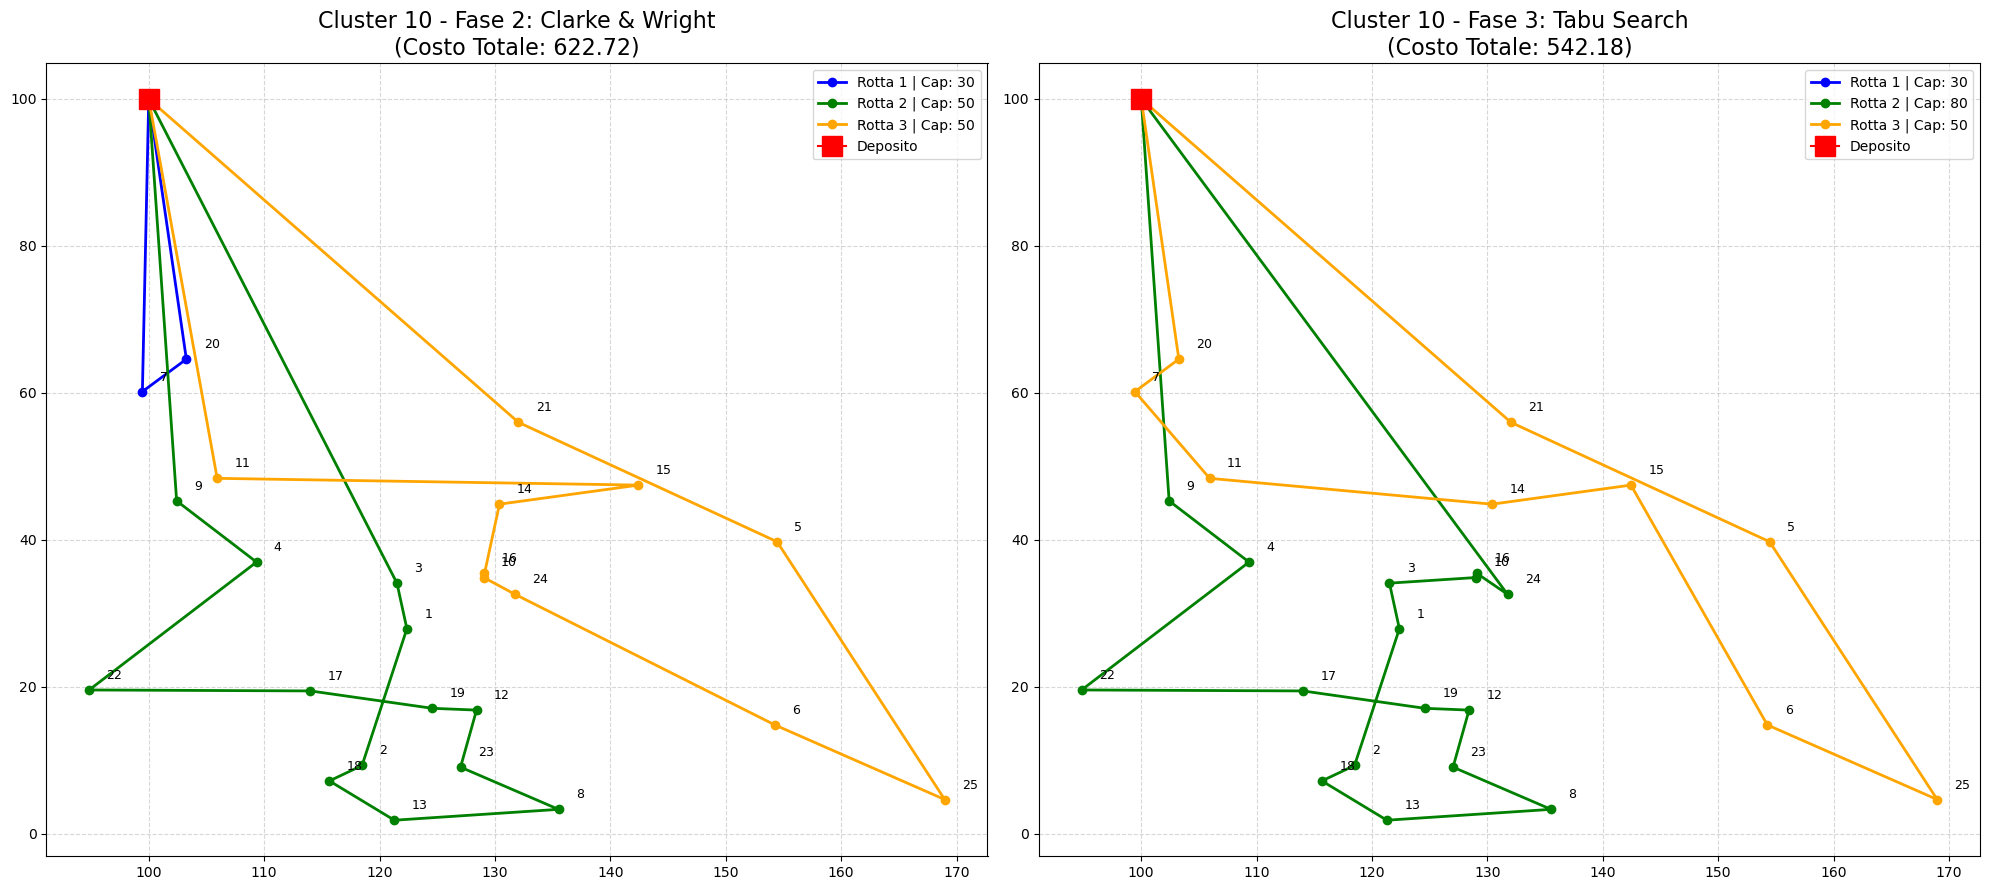

 Cluster  10 completato | Costo TS: 542.18 | Furgoni: 3


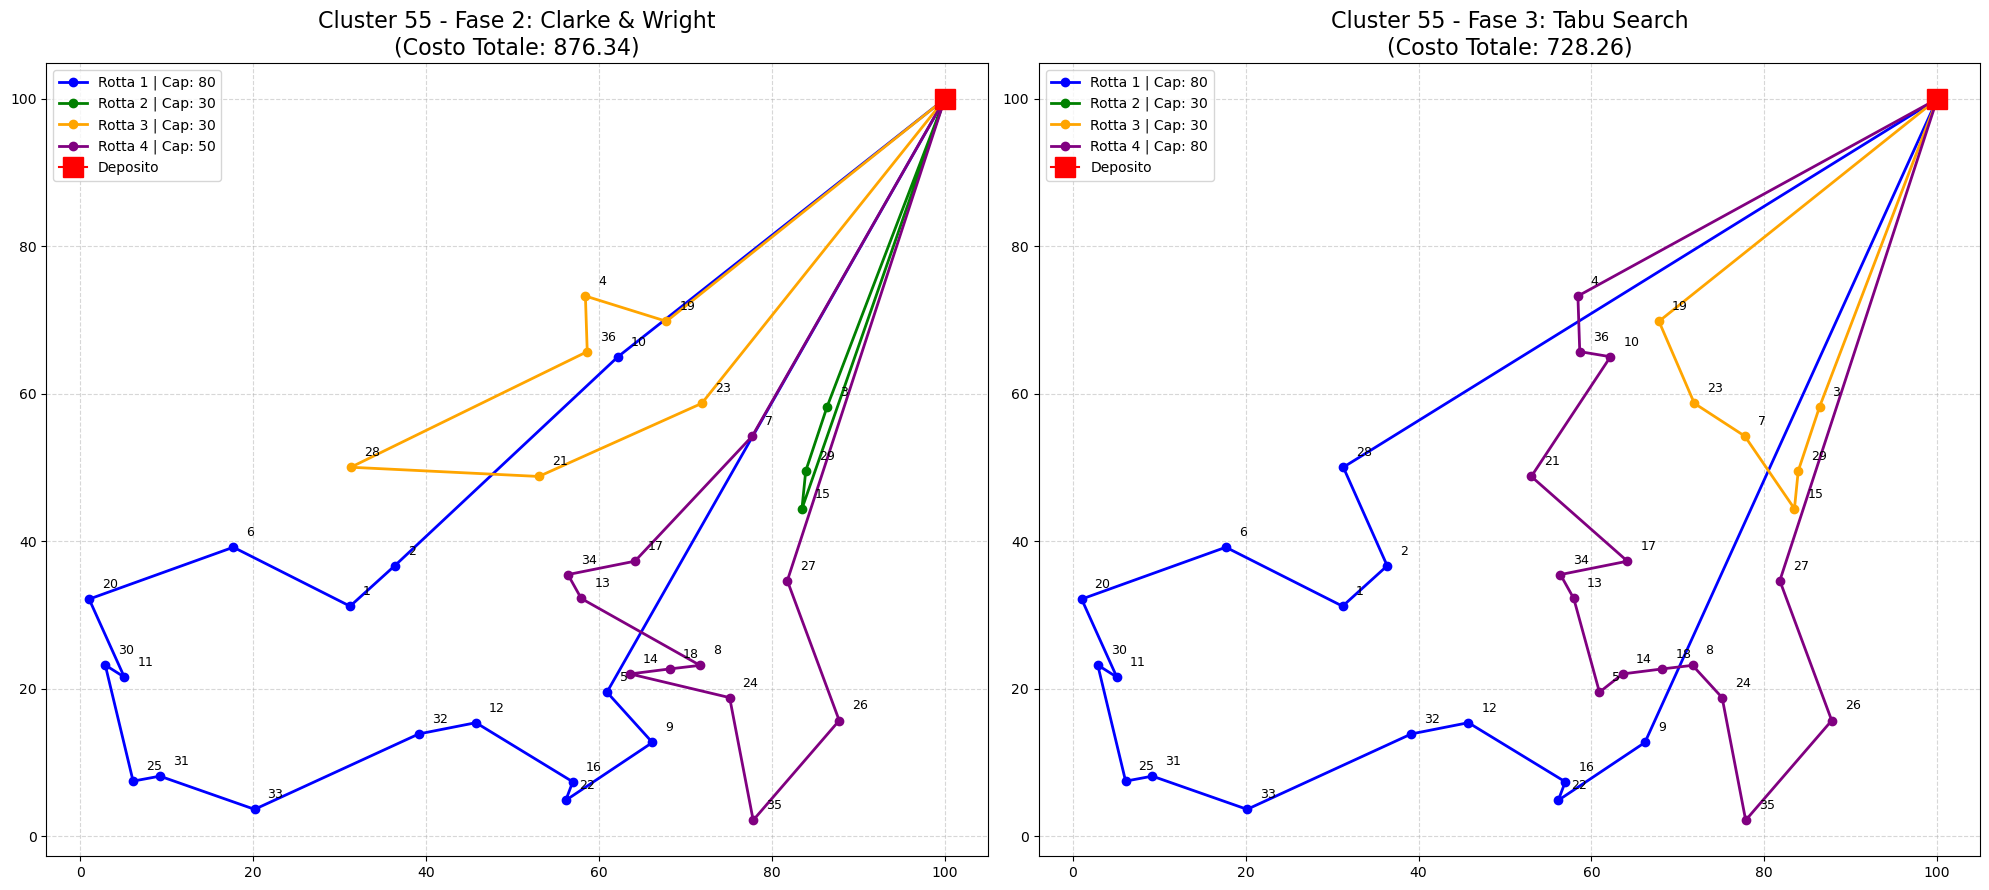

 Cluster  55 completato | Costo TS: 728.26 | Furgoni: 4


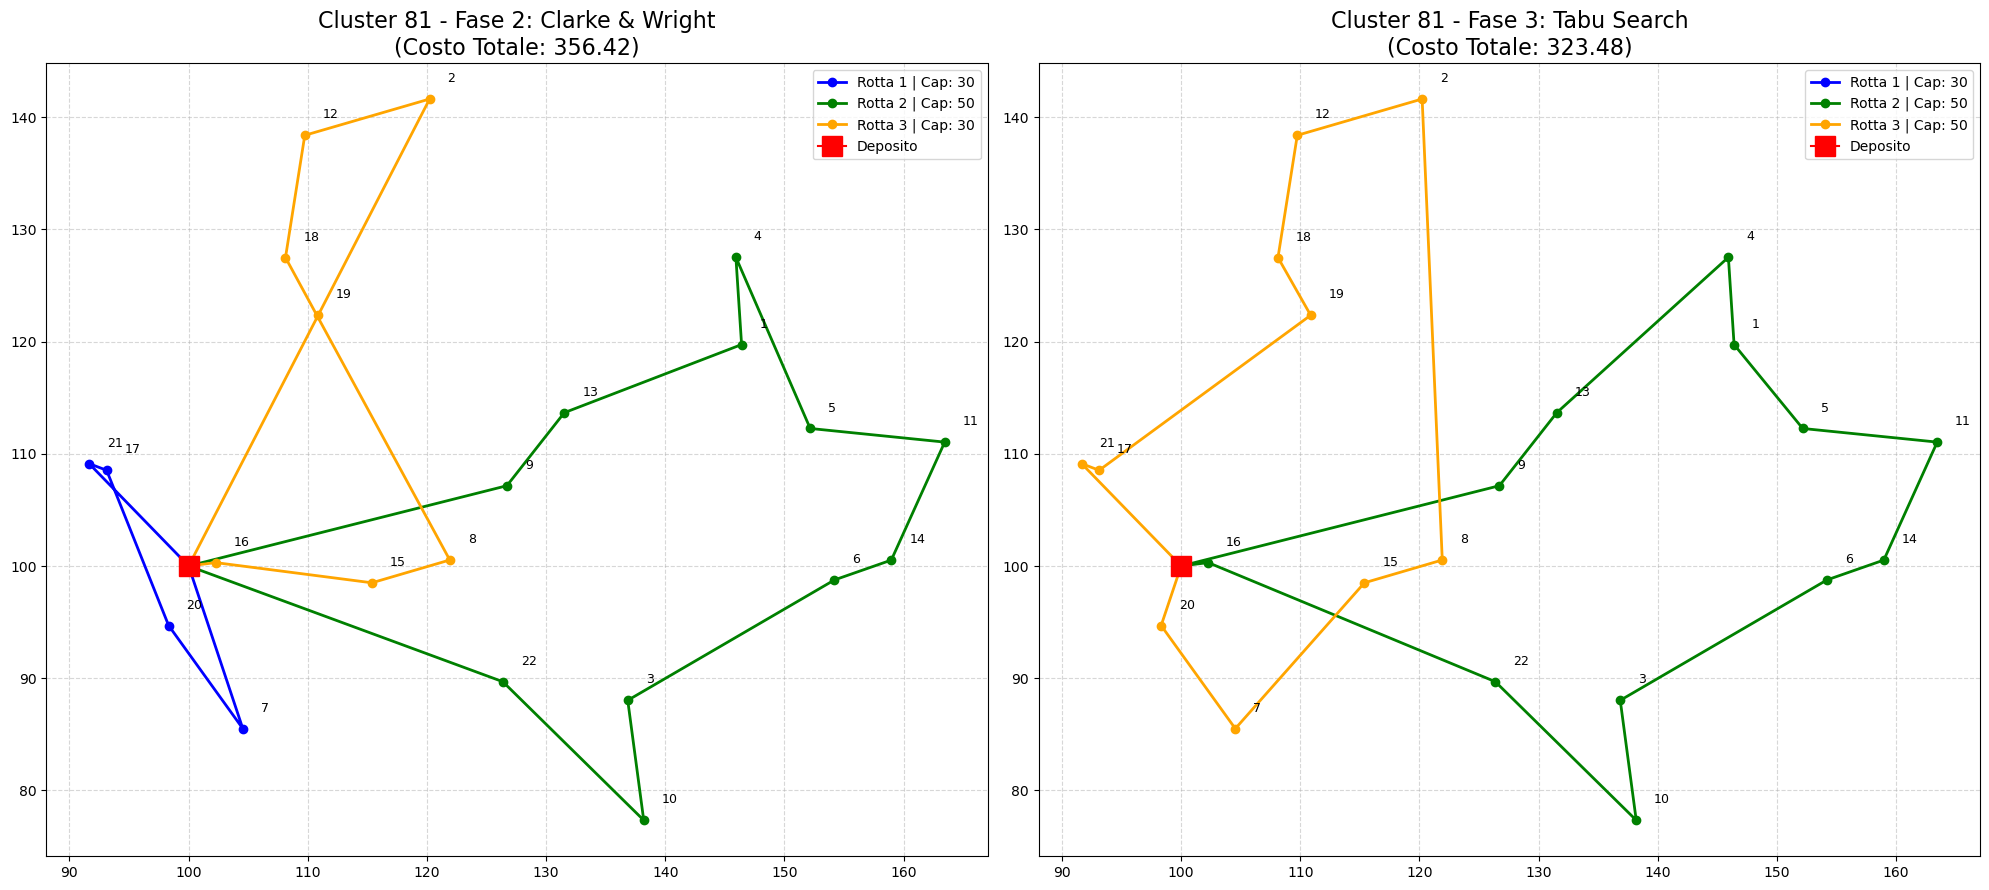

 Cluster  81 completato | Costo TS: 323.48 | Furgoni: 3


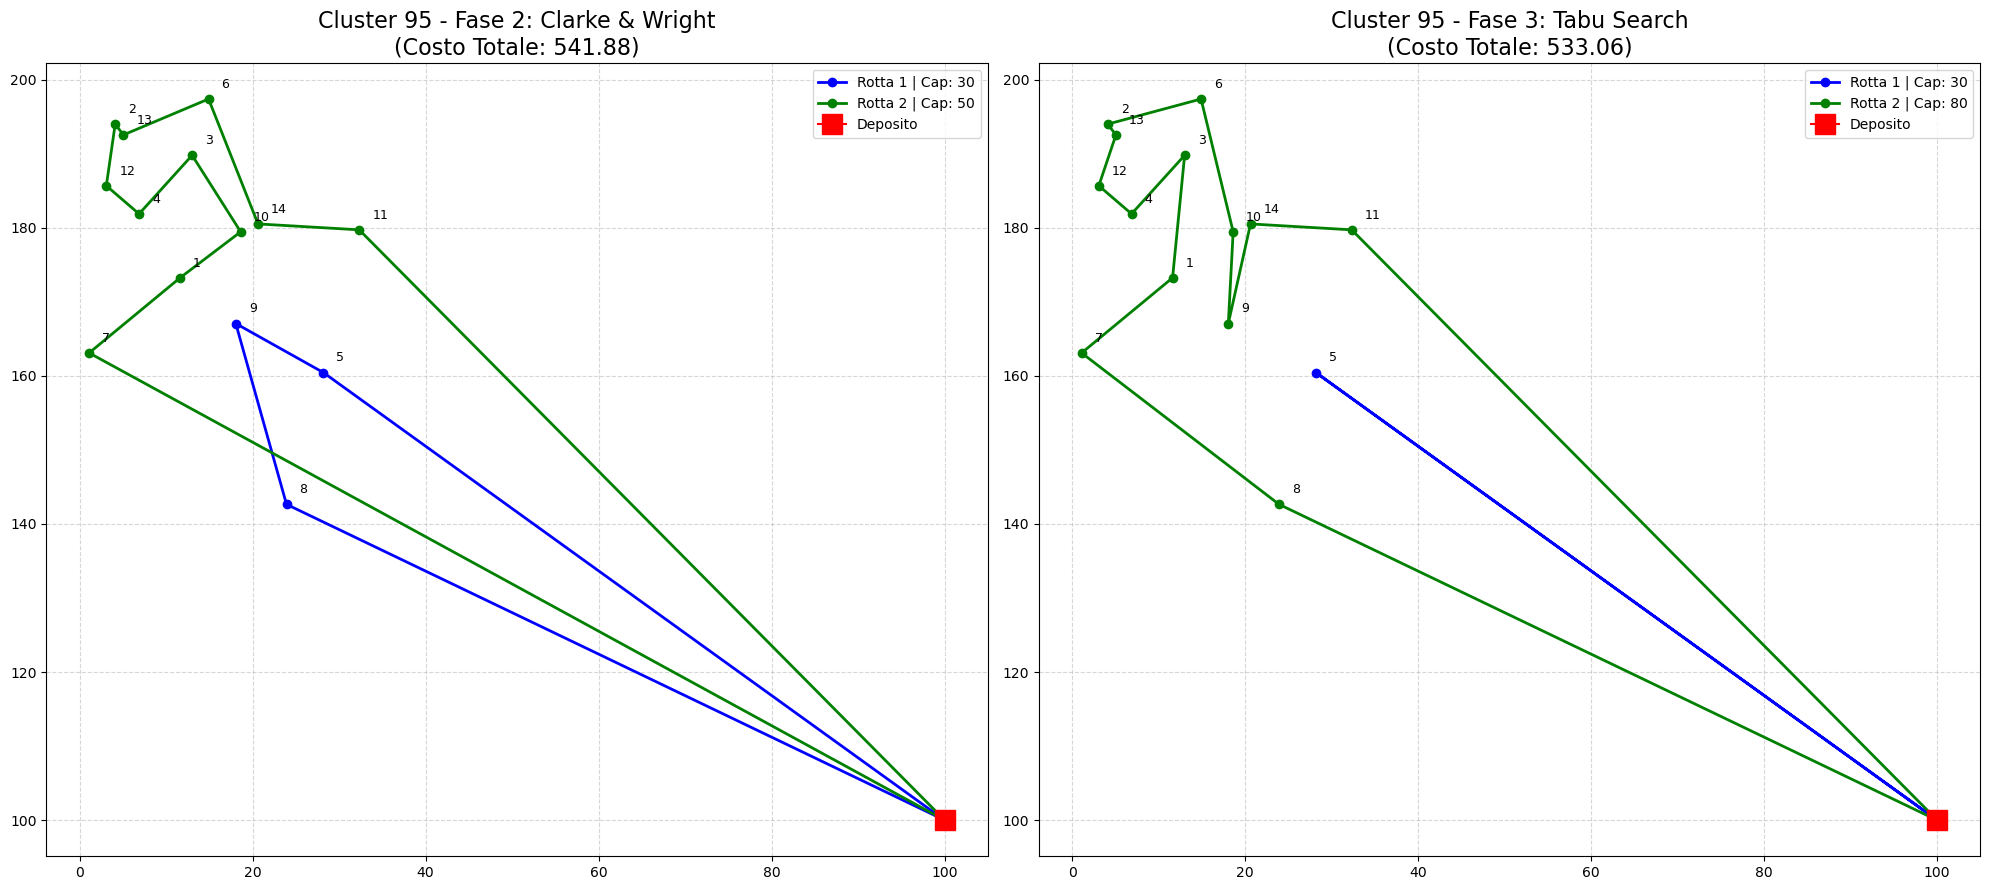

 Cluster  95 completato | Costo TS: 533.06 | Furgoni: 2


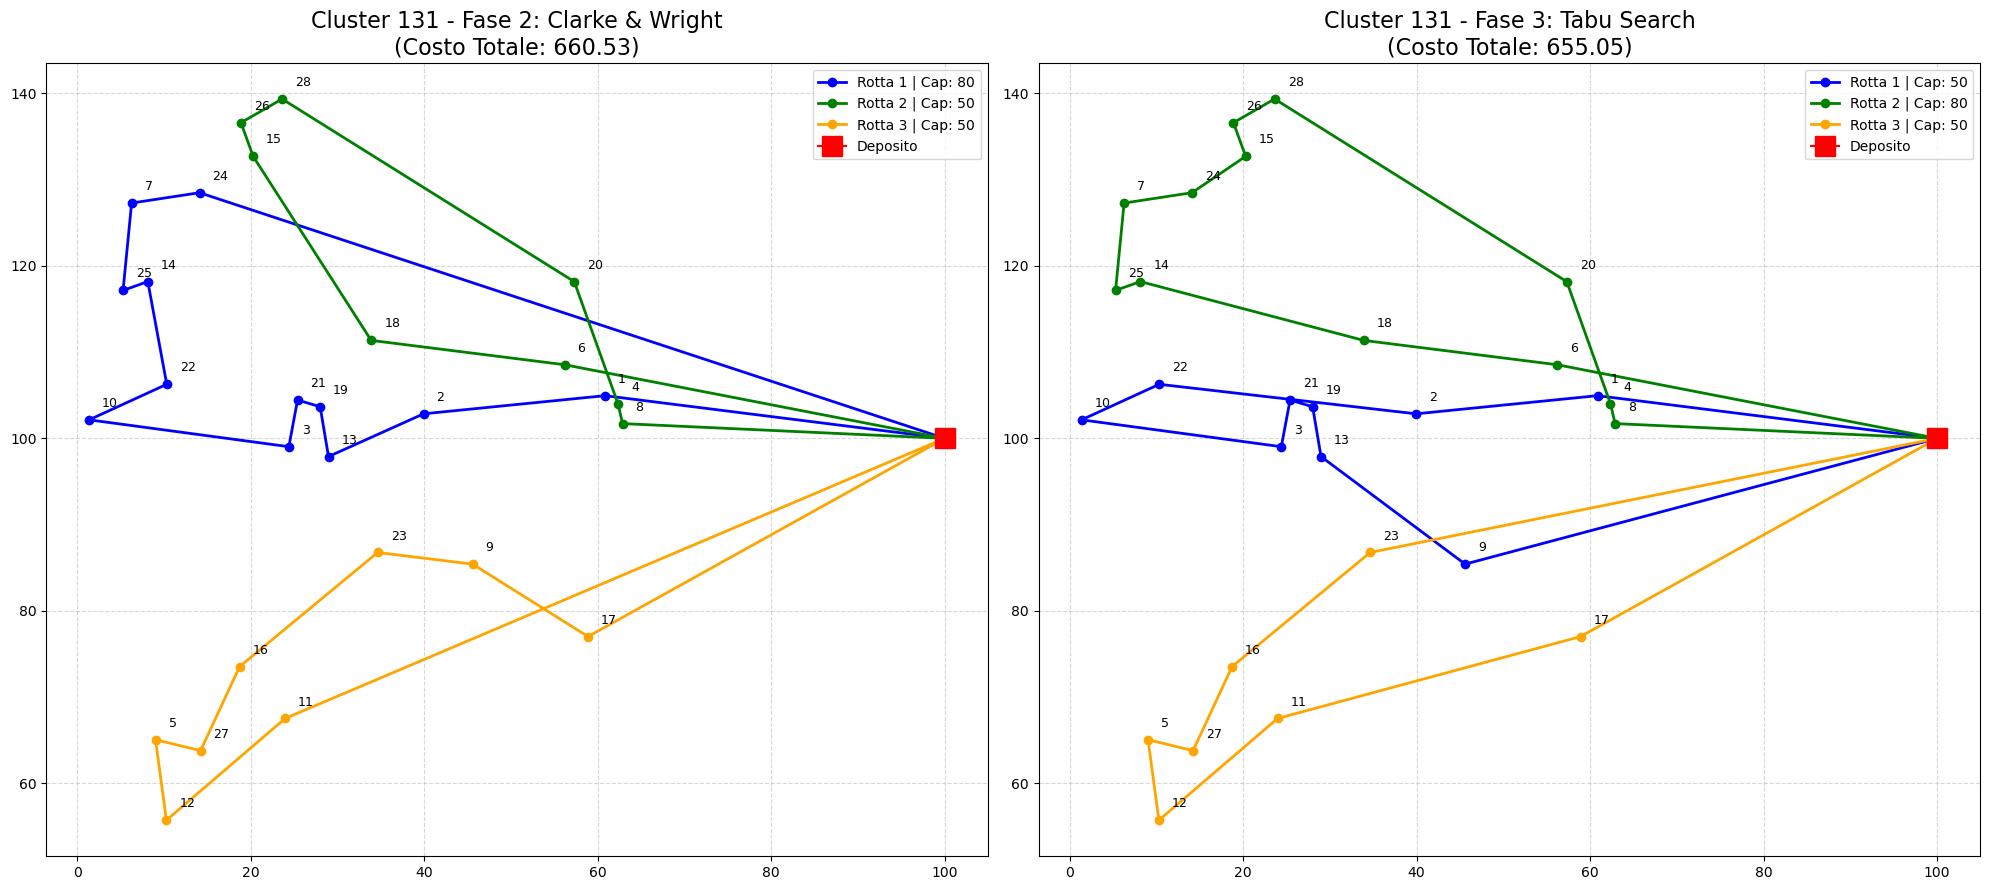

 Cluster 131 completato | Costo TS: 655.05 | Furgoni: 3


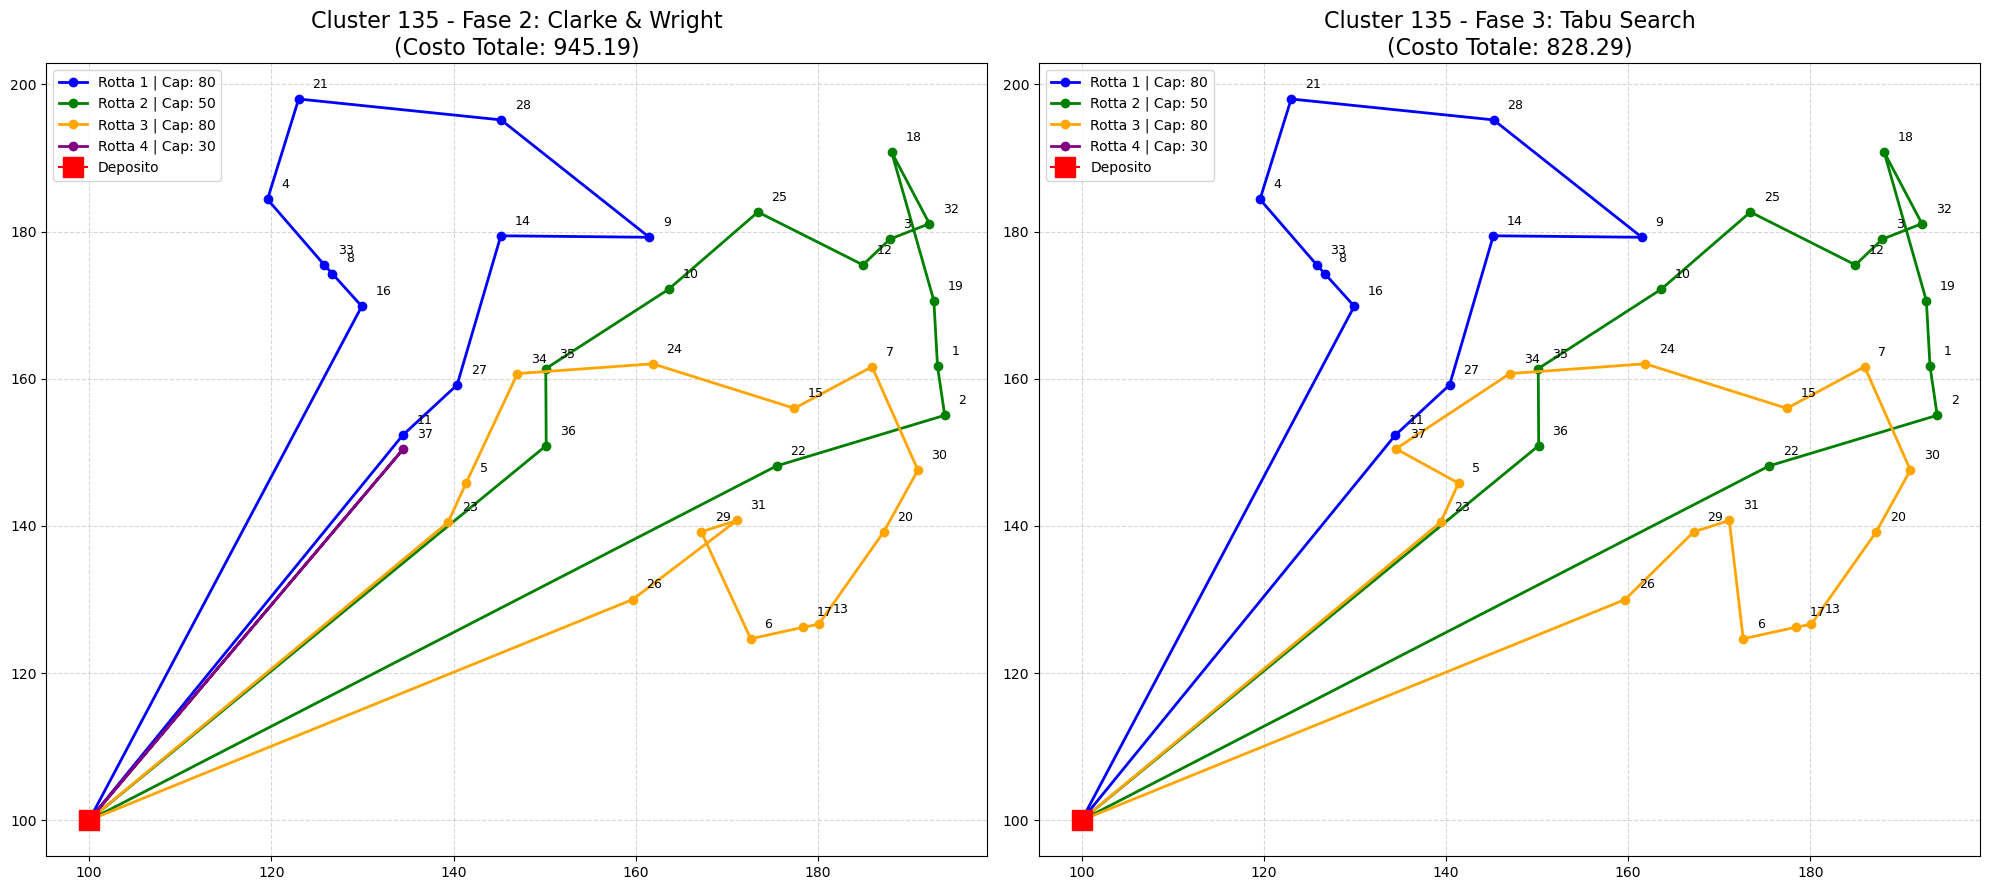

 Cluster 135 completato | Costo TS: 828.29 | Furgoni: 4


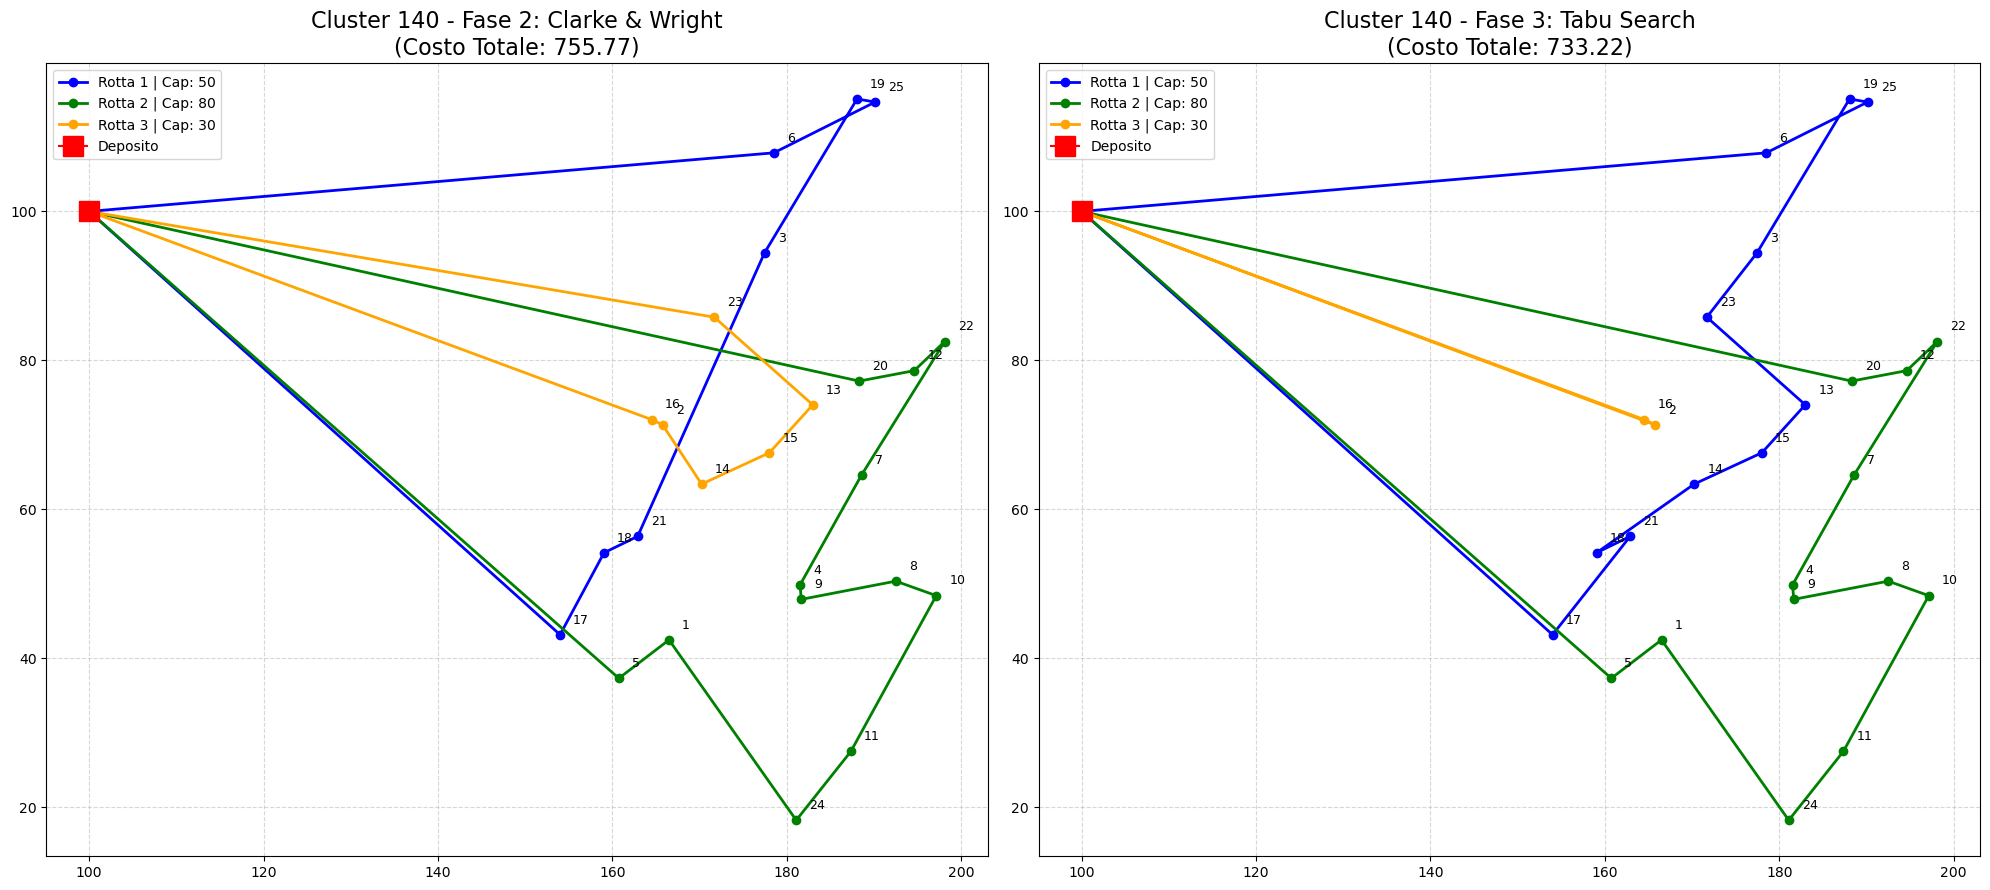

 Cluster 140 completato | Costo TS: 733.22 | Furgoni: 3


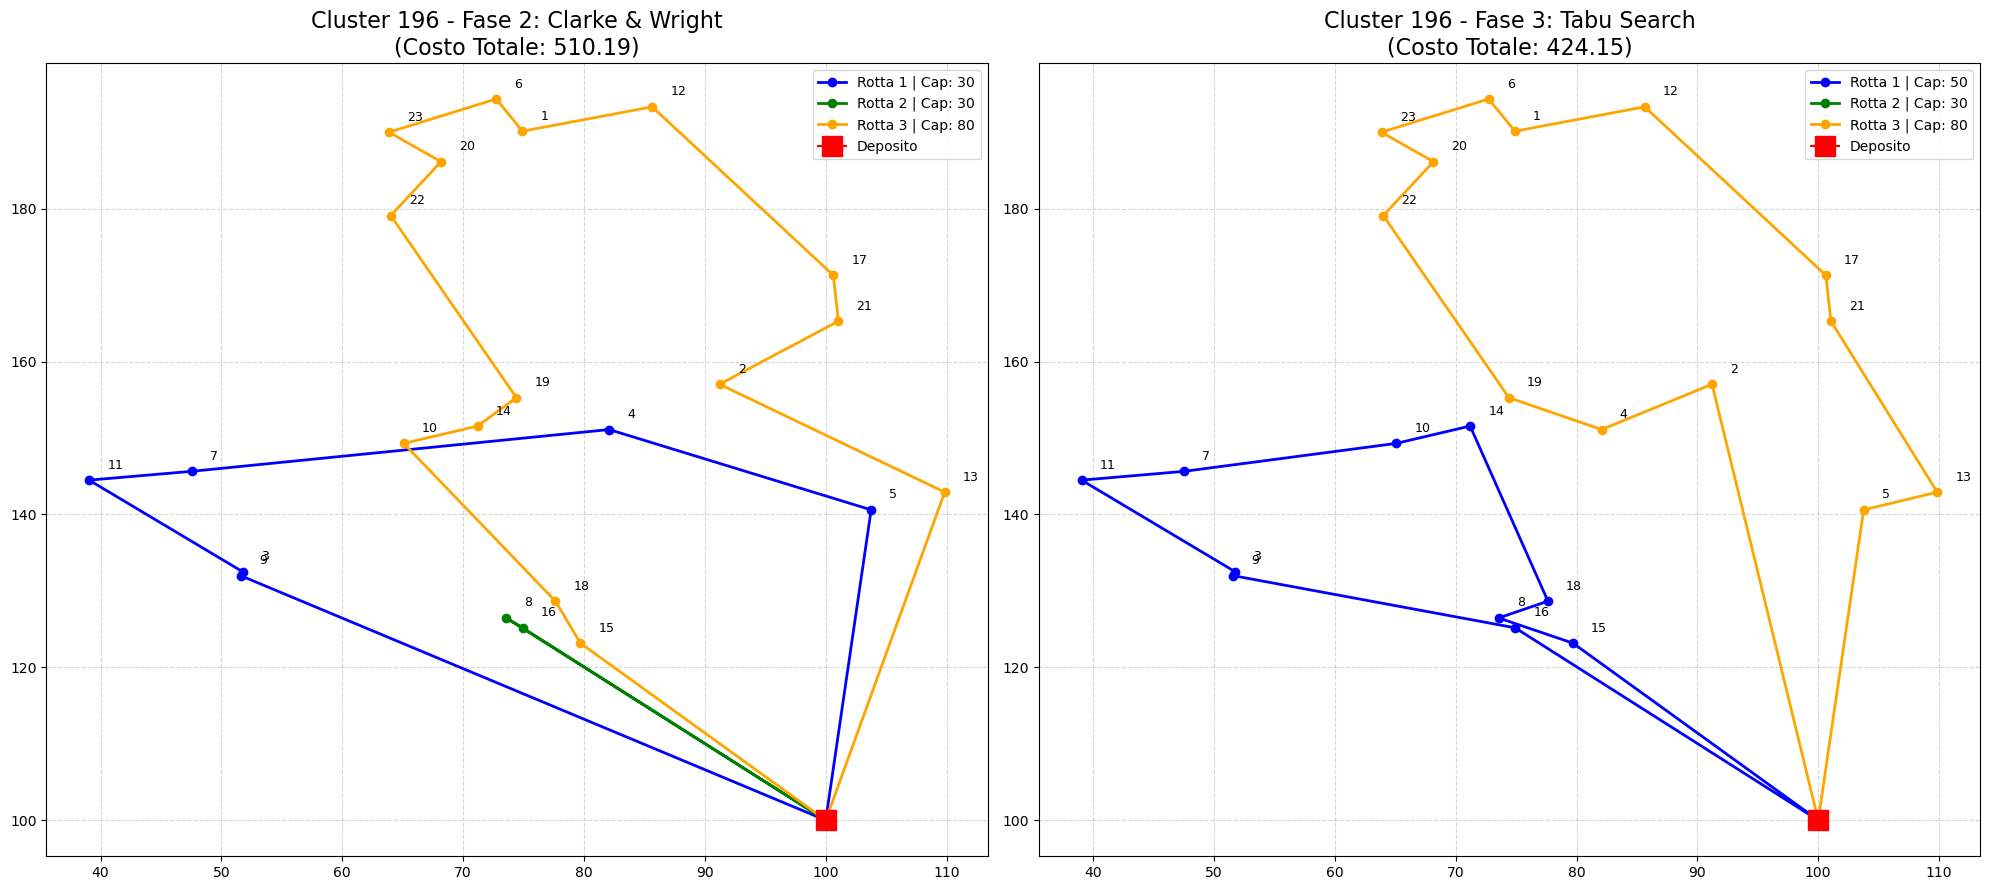

 Cluster 196 completato | Costo TS: 424.15 | Furgoni: 3


In [15]:
costo_totale_provincia = 0
furgoni_totali_provincia = 0
labels_cluster = []
costi_cw = []
costi_ts = []

print("\n" + "="*60)
print("   ELABORAZIONE GLOBALE DELLA PROVINCIA (8 CLUSTER)   ")
print("="*60)

for id_centro, nodi_cluster in clusters.items():
    
    # --- 1. SETUP DATI CLUSTER LOCALE ---
    N = len(nodi_cluster) + 1
    coords = np.zeros((N, 2))
    coords[0] = [100, 100]
    for local_idx, global_node in enumerate(nodi_cluster):
        coords[local_idx + 1] = coords_all[global_node]
        
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = math.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)
            
    deliveries, pickups = np.random.randint(1, 8, N), np.random.randint(1, 8, N)
    deliveries[0] = pickups[0] = 0
    tw_start, tw_end = np.zeros(N), np.full(N, 480)
    for i in range(1, N):
        if np.random.rand() > 0.5:
            tw_start[i] = np.random.randint(0, 200)
            tw_end[i] = tw_start[i] + np.random.randint(150, 300)
    tw_start[0], tw_end[0] = 0, 600

    # --- 2. RUN DEGLI ALGORITMI ---
    routes_cw = esegui_clarke_wright(N, dist, tw_start, tw_end, deliveries, pickups)
    costo_cw = sum(oracolo_ammissibilita(r, dist, tw_start, tw_end, deliveries, pickups)[1] for r in routes_cw)
    
    routes_ts, costo_ts = esegui_tabu_search(routes_cw, dist, tw_start, tw_end, deliveries, pickups)
    
    # Salvataggio Dati Globali
    labels_cluster.append(f"Cl. {id_centro}")
    costi_cw.append(costo_cw)
    costi_ts.append(costo_ts)
    costo_totale_provincia += costo_ts
    furgoni_totali_provincia += len(routes_ts)
    
    # =======================================================
    # --- 3. PLOT MAPPE DEL SINGOLO CLUSTER (FORMATTAZIONE ORIGINALE) ---
    # =======================================================
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'olive']

    # PLOT 1: Clarke & Wright
    ax1 = axes[0]
    for idx, route in enumerate(routes_cw): 
        color = colors[idx % len(colors)]
        x_c, y_c = [coords[n][0] for n in route], [coords[n][1] for n in route]
        _, _, v_cap = oracolo_ammissibilita(route, dist, tw_start, tw_end, deliveries, pickups)
        ax1.plot(x_c, y_c, marker='o', linestyle='-', color=color, linewidth=2, label=f'Rotta {idx+1} | Cap: {v_cap}')

    ax1.plot(coords[0][0], coords[0][1], marker='s', color='red', markersize=14, zorder=5, label='Deposito')
    for i in range(1, N): ax1.text(coords[i][0] + 1.5, coords[i][1] + 1.5, str(i), fontsize=9)
    ax1.set_title(f'Cluster {id_centro} - Fase 2: Clarke & Wright\n(Costo Totale: {costo_cw:.2f})', fontsize=16)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # PLOT 2: Tabu Search
    ax2 = axes[1]
    for idx, route in enumerate(routes_ts):
        color = colors[idx % len(colors)]
        x_c, y_c = [coords[n][0] for n in route], [coords[n][1] for n in route]
        _, _, v_cap = oracolo_ammissibilita(route, dist, tw_start, tw_end, deliveries, pickups)
        ax2.plot(x_c, y_c, marker='o', linestyle='-', color=color, linewidth=2, label=f'Rotta {idx+1} | Cap: {v_cap}')

    ax2.plot(coords[0][0], coords[0][1], marker='s', color='red', markersize=14, zorder=5, label='Deposito')
    for i in range(1, N): ax2.text(coords[i][0] + 1.5, coords[i][1] + 1.5, str(i), fontsize=9)
    ax2.set_title(f'Cluster {id_centro} - Fase 3: Tabu Search\n(Costo Totale: {costo_ts:.2f})', fontsize=16)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    # Salva le immagini con l'alta risoluzione richiesta (300 dpi) e il numero del cluster
    plt.savefig(f'mappa_rotte_cluster_{id_centro}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Cluster {id_centro:3d} completato | Costo TS: {costo_ts:.2f} | Furgoni: {len(routes_ts)}")

### Confronto Globale delle Prestazioni
Terminata l'elaborazione di tutti i cluster, mostriamo un grafico riepilogativo per evidenziare i risparmi sistematici ottenuti dalla Tabu Search rispetto alla soluzione costruttiva di base per l'intera provincia.

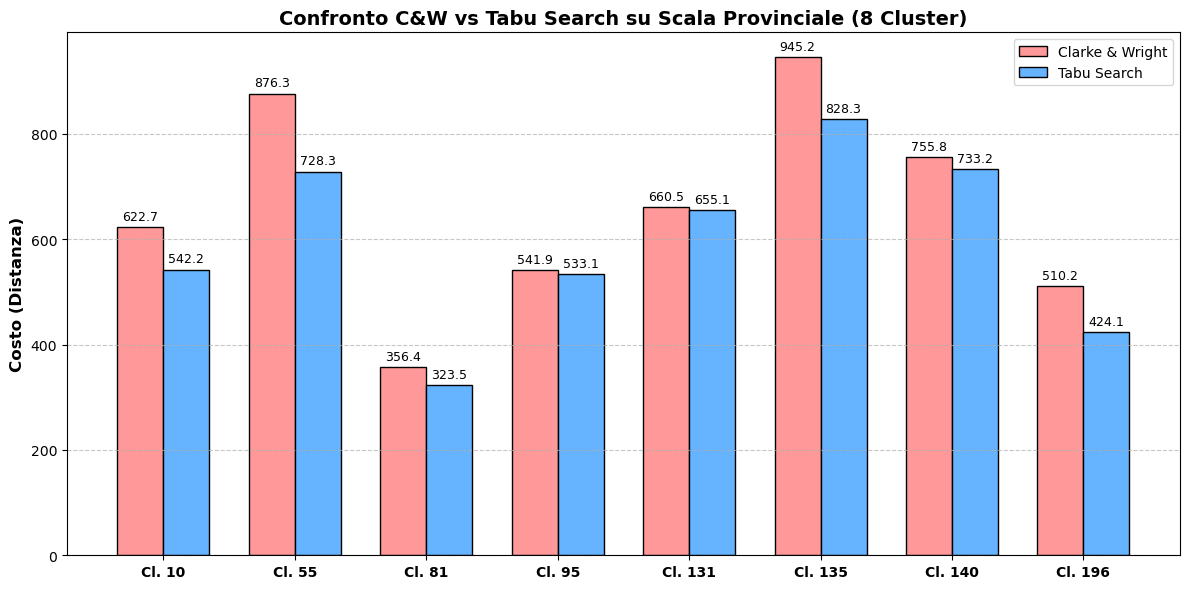


   RESOCONTO GLOBALE - RETE BIBLIOTECARIA PROVINCIALE   
Totale Cluster Gestiti    : 8
Totale Furgoni Impiegati  : 25
Distanza Totale Percorsa  : 4767.69 km


In [16]:
x = np.arange(len(labels_cluster))
width = 0.35

fig_bar, ax_bar = plt.subplots(figsize=(12, 6))
rects1 = ax_bar.bar(x - width/2, costi_cw, width, label='Clarke & Wright', color='#ff9999', edgecolor='black')
rects2 = ax_bar.bar(x + width/2, costi_ts, width, label='Tabu Search', color='#66b3ff', edgecolor='black')

ax_bar.set_ylabel('Costo (Distanza)', fontsize=12, fontweight='bold')
ax_bar.set_title('Confronto C&W vs Tabu Search su Scala Provinciale (8 Cluster)', fontsize=14, fontweight='bold')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels_cluster, fontweight='bold')
ax_bar.legend()
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax_bar.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('confronto_globale_algoritmi.png', dpi=300)
plt.show()

print("\n" + "="*60)
print("   RESOCONTO GLOBALE - RETE BIBLIOTECARIA PROVINCIALE   ")
print("="*60)
print(f"Totale Cluster Gestiti    : 8")
print(f"Totale Furgoni Impiegati  : {furgoni_totali_provincia}")
print(f"Distanza Totale Percorsa  : {costo_totale_provincia:.2f} km")
print("="*60)